<h1 style="color: White; font-weight: 800;">Capstone 1</h1>

<h2 style="color: blue; font-weight: 800;">
  Index : 
</h2>

<div class="nb-index">
  <ol>
    <li>
      <a href="#data-cleaning">Data Cleaning and Data Pre-processing</a>
      <ol>
        <li><a href="#importing-modules">Importing Modules</a></li>
        <li><a href="#data-ingestion">Data Ingestion</a></li>
        <li><a href="#column-name-meaning">Column Name Meaning</a></li>
        <li><a href="#column-name-changing">Column Name Changing</a></li>
        <li><a href="#category-columns">Category Columns</a></li>
        <li><a href="#binary-values-columns">Binary Values Columns</a></li>
        <li><a href="#numerical-columns">Numerical Columns</a></li>
        <li><a href="#null-value-treatment">NULL Values Treatment</a></li>
      </ol>
    </li>
  </ol>
</div>

 <a id="data-cleaning"></a>

<h1 style="color: red; font-weight: 800;">Data Cleaning and Data Pre-processing</h1>

 <a id="importing-modules"></a>

<h2 style="color: green; font-weight: 800;">Importing Modules</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

<a id="data-ingestion"></a>

<h2 style="color: green; font-weight: 800;">Data Ingestion</h2>

In [2]:
df = pd.read_csv("HR_HIRING_ANALYTICS.csv")


data = pd.DataFrame(df)
# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Convert updated column names to the names used in your existing code
column_mapping = {
    "CANDIDATE_REF": "Candidate_Ref",
    "DOJ_EXTENDED": "DOJ_Extended",
    "DURATION_TO_ACCEPT_OFFER": "Duration_to_accept_offer",
    "NOTICE_PERIOD": "Notice_Period",
    "OFFERED_BAND": "Offered_Band",
    "PERCENT_HIKE_EXPECTED_IN_CTC": "Percent_hike_expected_in_CTC",
    "PERCENT_HIKE_OFFERED_IN_CTC": "Percent_hike_offered_in_CTC",
    "PERCENT_DIFFERENCE_CTC": "Percent_difference_CTC",
    "JOINING_BONUS": "Joining_Bonus",
    "CANDIDATE_RELOCATE_ACTUAL": "Candidate_relocate_actual",
    "GENDER": "Gender",
    "CANDIDATE_SOURCE": "Candidate_Source",
    "REX_IN_YRS": "Rex_in_Yrs",
    "LOCATION_ID": "Location_ID",
    "POSTAL_CODE": "Postal_Code",
    "AGE": "Age",
    "LOB_ID": "LOB_Id",
    "DOMICILE_ID": "Domicile_Id",
    "JOINING_STATUS": "Status",
    "DATE_OF_INTERVIEW": "Date_of_Interview",
    "LOB_NAME": "LOB",
    "DOMICILE_NAME": "Domicile_Name",
    "LOCATION_NAME": "Location_Name",
    "REGION_ID": "Region_Id",
    "REGION_NAME": "Region_Name"
}

data.rename(columns=column_mapping, inplace=True)

# Add Sno if it is not present in the updated file
if "Sno" not in data.columns:
    data.insert(0, "Sno", range(1, len(data) + 1))

# Verify the final column names
print(data.columns.tolist())

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [3]:
# df = pd.read_csv("HR_Hiring_details_transaction.csv")
# df
# data = pd.DataFrame(df)


In [4]:
data

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


In [5]:
cols = list(data.columns)
print(cols)

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [6]:
row,column = data.shape
print(f"No of Rows : {row}\nNo of Columns = {column}")

No of Rows : 8995
No of Columns = 26


In [7]:
data.head()

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [8]:
data.sample(10)

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
1084,1085,2218193,No,16,30,E2,38.30,38.30,0.00,No,...,25.0,2,D2,Joined,2013-04-22,INFRA,Bihar,Noida,R1,North
7743,7744,3395836,Yes,3,30,E2,50.00,13.13,-36.87,No,...,34.0,1,D19,Not Joined,2014-07-06,ERS,Tamil Nadu,Noida,R1,North
3539,3540,2483473,No,2,30,E2,50.00,73.33,23.33,No,...,28.0,2,D2,Joined,2014-02-01,INFRA,Bihar,Chennai,R2,South
5509,5510,3046065,Yes,32,30,E1,48.81,48.81,0.00,No,...,25.0,4,D22,Joined,2013-07-12,BFSI,Uttar Pradesh,Bangalore,R2,South
5079,5080,2851099,No,30,30,E1,87.79,111.27,23.48,No,...,26.0,1,D11,Joined,2013-05-17,ERS,Karnataka,Chennai,R2,South
3888,3889,2565039,No,13,90,E2,46.01,46.01,0.00,No,...,28.0,4,D11,Not Joined,2013-10-16,BFSI,Karnataka,Mumbai,R4,West
2449,2450,2378082,No,3,30,E1,61.29,45.16,-16.13,No,...,26.0,4,D20,Joined,2013-10-10,BFSI,Telangana,Bangalore,R2,South
131,132,2537925,Yes,47,60,E3,45.83,51.04,5.21,No,...,34.0,2,D17,Joined,2013-03-22,INFRA,Punjab,Noida,R1,North
6871,6872,3300424,Yes,73,30,E1,38.30,38.30,0.00,No,...,29.0,3,D16,Joined,2014-02-12,Healthcare,Odisha,Chennai,R2,South
3829,3830,2560753,No,81,60,E1,38.46,26.15,-12.31,No,...,30.0,4,D3,Joined,2013-06-25,BFSI,Chandigarh,Chennai,R2,South


<a id="column-name-meaning"></a>

<h2 style="color: green; font-weight: 800;">Column Name Meaning</h2>

1.
*`CANDIDATE_REF`*
Unique reference number assigned to the candidate


2.
*`DOJ_EXTENDED`*
Indicates whether the candidate’s date of joining was extended


3.
*`DURATION_TO_ACCEPT_OFFER`*
Number of days taken by the candidate to accept the offer


4.
*`NOTICE_PERIOD`*
Notice period, generally measured in days, required by the candidate’s previous employer


5.
*`OFFERED_BAND`*
Job grade or employment level offered to the candidate


6.
*`PERCENT_HIKE_EXPECTED_IN_CTC`*
Percentage increase in CTC expected by the candidate


7.
*`PERCENT_HIKE_OFFERED_IN_CTC`*
Percentage increase in CTC offered by the organization


8.
*`PERCENT_DIFFERENCE_CTC`*
Percentage gap between the expected CTC hike and the offered CTC hike


9.
*`JOINING_BONUS`*
Indicates whether a joining bonus was offered


10.
*`CANDIDATE_RELOCATE_ACTUAL`*
Indicates whether relocation was required or accepted by the candidate


11.
*`GENDER`*
Gender of the candidate


12.
*`CANDIDATE_SOURCE`*
Recruitment source through which the candidate was identified or approached


13.
*`REX_IN_YRS`*
Relevant or related work experience in years


14.
*`LOCATION_ID`*
Unique code representing the job or organization location


15.
*`POSTAL_CODE`*
Postal code associated with the job or organization location


16.
*`AGE`*
Age of the candidate


17.
*`LOB_ID`*
Unique code representing the candidate’s Line of Business or department


18.
*`DOMICILE_ID`*
Unique code representing the candidate’s home state or residential location


19.
*`JOINING_STATUS`*
Outcome of the offer, such as joined, not joined, or declined


20.
*`DATE_OF_INTERVIEW`*
Date on which the candidate interview was conducted


22.
*`LOB_NAME`*
Name of the candidate’s Line of Business or department


23.
*`DOMICILE_NAME`*
Name of the candidate’s home state or residential location


24.
*`LOCATION_NAME`*
Name of the job or organization location


4.
*`REGION_ID`*
Unique code representing the region


25.
*`REGION_NAME`*
Name of the region associated with the location

<a id="column-name-changing"></a>

<h2 style="color: green; font-weight: 800;">Column Name Changing</h2>

`Changing columns' name to more relatable name`

1. *Candidate_Ref* = **Candidate_ID**
2. *Duration_to_accept_offer* = **Acceptance_days**
3. *Percent_hike_expected_in_CTC* = **Expected_CTC_hike_pct**
4. *Percent_hike_offered_in_CTC* = **Offered_CTC_hike_pct**
5. *Percent_difference_CTC* = **CTC_diff_pct**
6. *Rex_in_Yrs* = **Experience_years**


In [9]:
data.rename(columns = {"Candidate_Ref" : "Candidate_ID", "Duration_to_accept_offer" : "Acceptance_days"
                      ,"Percent_hike_expected_in_CTC" : "Expected_CTC_hike_pct", "Percent_hike_offered_in_CTC" : "Offered_CTC_hike_pct",
                      "Percent_difference_CTC" : "CTC_diff_pct", "Rex_in_Yrs" : "Experience_years"}, inplace=True)

data.head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [10]:
cols = list(data.columns)
print(f"Columns = {cols}")

Columns = ['Sno', 'Candidate_ID', 'DOJ_Extended', 'Acceptance_days', 'Notice_Period', 'Offered_Band', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Experience_years', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


<a id="category-columns"></a>

<h2 style="color: green; font-weight: 800;">Category Columns</h2>

`nan value only in Offered_Band`

In [11]:
category_cols = list(data.select_dtypes(exclude='number').columns)
print(f"Category columns = {category_cols}")

Category columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [12]:

# There is Null values in ->
# 1.Offered_Band
# 2.Location_ID

<a id="binary-values-columns"></a>

<h2 style="color: green; font-weight: 800;">Binary Values Columns</h2>

`There is no inconsistency as there is only 'Yes' or 'No'`

<a id="numerical-columns"></a>

<h2 style="color: green; font-weight: 800;">Numerical Columns</h2>


In [13]:
numerical_cols = list(data.select_dtypes(include = 'number').columns)
print(f"Numerical columns = {numerical_cols}")

Numerical columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [14]:
data[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8980 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


### Checking for NULL values

In [15]:
data[numerical_cols].isna().sum()

# There is NULL values in ->
# 1. Age 

Sno                       0
Candidate_ID              0
Acceptance_days           0
Notice_Period             0
Expected_CTC_hike_pct     0
Offered_CTC_hike_pct      0
CTC_diff_pct              0
Experience_years          0
Postal_Code               0
Age                      15
LOB_Id                    0
dtype: int64

In [16]:
data['Age'].isna().sum()

np.int64(15)

In [17]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

### Checking for duplicate values

In [18]:
data[numerical_cols].duplicated().sum()
# There is no duplicate value in numerical columns

np.int64(0)

`Columns to check further - Either will change data type or remove in EDA`

- Postal_Code
- LOB_Id

In [19]:
data['Postal_Code'].unique()

array([201301, 600020, 122107, 560034, 500004, 700027, 682001, 411002,
       600018, 400001, 560002, 382460, 560063, 500045, 411006])

In [20]:
data['LOB_Id'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
data['Notice_Period'].unique()
# Have to deep it as numeric (Imp)

array([ 30,  45, 120,   0,  75,  60,  90])

In [22]:
data['Acceptance_days'].unique()
# There is no negative(-) value, so this column is not imbalance.

array([ 14,  18,   3,  26,   1,  17,  37,  16,   6, 120,  44,   7,  98,
         0,  83,  32,  19,   4,  38,  24,  10,  53,   5,  46,   2,  31,
        54,  33, 105,  69,  68,  84,  28, 126, 106,  90,  21,  36,  34,
        20,  13,   8,  42,  12, 103,  43,  60,  23,  67,  15,  45,  25,
        47,  11,  48,  74,  30,  40,  35,  58,  29,  86,  51,  50,  39,
        57,  93,  55,  71,  56,  66,  62,   9,  64, 107,  27,  78,  22,
        49,  92,  61,  79,  77, 108,  70,  82, 210,  80,  97,  41,  59,
        88,  99,  63, 111,  87,  95,  52,  96,  91, 101,  65, 140,  76,
        73, 123, 104,  72, 117, 109,  89, 127,  81,  85,  75, 118, 114,
       110, 129, 124, 116, 181,  94, 121, 119, 102, 113, 115, 125, 131,
       100, 130, 224, 143, 122, 163])

In [23]:
print(data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0])
# There are many rows that have offered ctc hike percentage in negative value.
# So this negative values are important, because candidates with negative value of percentage ctc hike might not join the firm
print(f"\nNo of rows with negative(-) offered ctc hike percentage = {data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0].count()}")

7      -20.00
8      -22.22
10     -60.53
15     -27.31
29      -2.17
        ...  
8872   -17.04
8882    -6.67
8958    -2.86
8967   -10.00
8977   -14.29
Name: Offered_CTC_hike_pct, Length: 446, dtype: float64

No of rows with negative(-) offered ctc hike percentage = 446


<a id="null-value-treatment"></a>

<h2 style="color: green; font-weight: 800;">NULL Values Treatment</h2>

`Columns with NULL values :`

1. Age
2. Offered_Band
3. Location_ID
4. Location_Name                
5. Region_Id                    
6. Region_Name 

In [24]:
data.isna().sum()

# One thing here -> 
# The Data type of Location_ID is object, but its showing 0 null value here. That means there is NULL value as Object.

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                          15
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        8995 non-null   int64  
 1   Candidate_ID               8995 non-null   int64  
 2   DOJ_Extended               8995 non-null   object 
 3   Acceptance_days            8995 non-null   int64  
 4   Notice_Period              8995 non-null   int64  
 5   Offered_Band               8995 non-null   object 
 6   Expected_CTC_hike_pct      8995 non-null   float64
 7   Offered_CTC_hike_pct       8995 non-null   float64
 8   CTC_diff_pct               8995 non-null   float64
 9   Joining_Bonus              8995 non-null   object 
 10  Candidate_relocate_actual  8995 non-null   object 
 11  Gender                     8995 non-null   object 
 12  Candidate_Source           8995 non-null   object 
 13  Experience_years           8995 non-null   int64

## Treatment of `Age` column

In [26]:
data['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
8980 non-null   float64
dtypes: float64(1)
memory usage: 70.4 KB


In [27]:
data['Age']

0       34.0
1       34.0
2       27.0
3       34.0
4       34.0
        ... 
8990    34.0
8991    34.0
8992    34.0
8993    34.0
8994    34.0
Name: Age, Length: 8995, dtype: float64

In [28]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

In [29]:
Age_missing = int(data['Age'].isna().sum())
Age_min = data['Age'].min()
Age_max = data['Age'].max()

Age_median = data['Age'].median()
Age_mean = data['Age'].mean()

print(f"Null values in Age column = {Age_missing}")
print(f"Min Age = {Age_min}")
print(f"Max Age = {Age_max}")
print(f"Median Age = {Age_median}")
print(f"Mean Age = {Age_mean}")

Null values in Age column = 15
Min Age = 20.0
Max Age = 60.0
Median Age = 29.0
Mean Age = 29.912026726057906


In [30]:
data['Age'][data["Age"] > Age_mean].count()

np.int64(4481)

In [31]:
data['Age'][data["Age"] <= Age_mean].count()

np.int64(4499)

In [32]:
data['Age'][data["Age"] > 35].count()

np.int64(435)

In [33]:
data['Age'][data["Age"] > 40].count()

np.int64(77)

In [34]:
data['Age'][data["Age"] > 50].count()

np.int64(2)

### Diagram of Age column distribution

In [35]:
age_count = pd.DataFrame(data['Age'].dropna().value_counts())
age_count

,count
Age,
34.0,2142
27.0,903
26.0,839
28.0,770
25.0,676
29.0,630
30.0,575
31.0,485
24.0,397


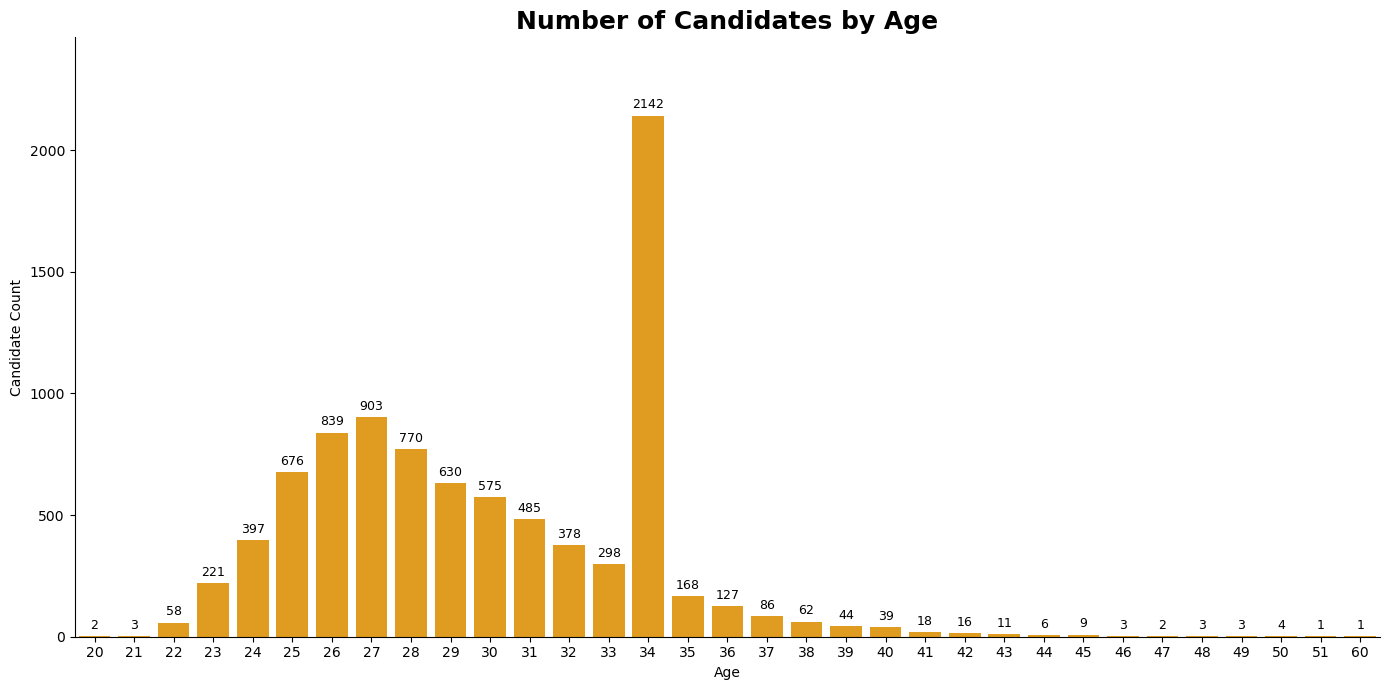

In [36]:
age_count2 = (
    data["Age"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

x = age_count2.index.tolist()
y = age_count2.tolist()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=x,
    y=y,
    color="orange"
)

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.title("Number of Candidates by Age", fontsize=18, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Candidate Count")
plt.ylim(0, max(y) * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

### Outliers check for `Age` column

In [37]:
age = pd.to_numeric(data["Age"].dropna())

# Calculate IQR
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = age[(age < lower_bound) | (age > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values : {outliers.unique()}")

Q1: 27.0
Q3: 34.0
IQR: 7.0
Lower bound: 16.5
Upper bound: 44.5
Number of outliers: 26
Outlier values : [50. 45. 46. 49. 47. 48. 60. 51.]


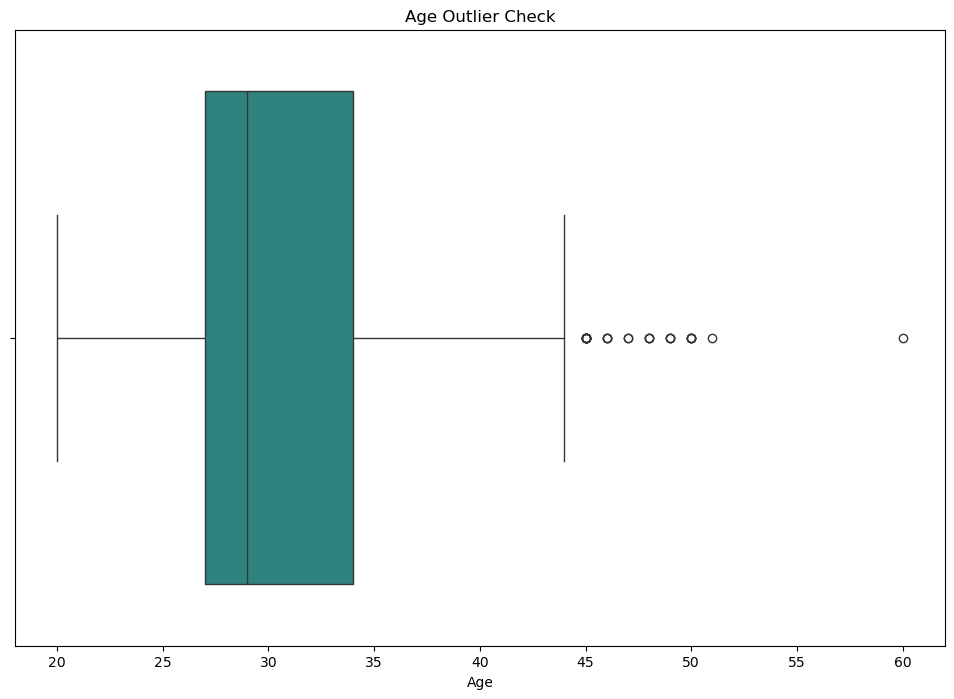

In [38]:
plt.figure(figsize=(12,8))

sns.boxplot(x=data["Age"].dropna(), palette='viridis')

plt.title("Age Outlier Check")
plt.xlabel("Age")
plt.show()

The decreasing number of candidates at higher ages indicates that the distribution is concentrated around younger ages and has a right tail. The mean age is approximately 29.91, while the median is 29. The IQR method flags ages above 44.5 as statistical outliers.
Because the higher ages can pull the mean upward, the median is the safer replacement value for the 15 missing ages. It represents the typical candidate more robustly and results in an actual whole-number age.

In [39]:
data[data['Age'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
397,398,2117861,Yes,62,60,E2,40.85,40.85,0.00,No,...,NaN,2,D15,Joined,2013-10-26,INFRA,Manipur,Noida,R1,North
406,407,2118480,No,4,30,E1,89.66,48.28,-41.38,No,...,NaN,5,D12,Joined,2014-03-30,CSMP,Kerala,Noida,R1,North
414,415,2119541,Yes,2,0,E2,56.86,37.25,-19.61,No,...,NaN,2,D15,Joined,2014-04-08,INFRA,Manipur,Noida,R1,North
425,426,2121112,No,3,30,Not Assigned,0.00,-6.45,-6.45,No,...,NaN,2,D4,Joined,2014-04-25,INFRA,Chhattisgarh,Bangalore,R2,South
446,447,2128251,No,58,30,E2,50.33,50.33,0.00,No,...,NaN,2,D24,Joined,2014-05-20,INFRA,West Bengal,Chennai,R2,South
485,486,2143765,Yes,41,90,E1,10.77,10.77,0.00,No,...,NaN,4,D7,Joined,2014-07-06,BFSI,Gujarat,Chennai,R2,South
526,527,2151137,No,4,45,E3,20.83,20.83,0.00,No,...,NaN,2,D23,Joined,2014-04-13,INFRA,Uttarkhand,Noida,R1,North
573,574,2160044,No,0,0,E2,17.78,14.31,-3.47,Yes,...,NaN,2,D13,Joined,2014-06-19,INFRA,Madhya Pradesh,Gurgaon,R1,North
616,617,2167868,No,5,30,E1,20.00,-4.00,-24.00,No,...,NaN,2,D13,Joined,2013-01-02,INFRA,Madhya Pradesh,Noida,R1,North
674,675,2177940,No,0,30,E1,13.46,34.56,21.10,No,...,NaN,5,D22,Joined,2013-01-22,CSMP,Uttar Pradesh,Gurgaon,R1,North


### Filling NULL values in `Age` column with `Median`

In [40]:
data['Age'].fillna(Age_median, inplace=True)

In [41]:
data['Age'].isna().sum()

np.int64(0)

In [42]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

## Treatment of `Offered_Band` column

In [43]:
data['Offered_Band']

0       E2
1       E2
2       E2
3       E2
4       E2
        ..
8990    E1
8991    E1
8992    E2
8993    E1
8994    E1
Name: Offered_Band, Length: 8995, dtype: object

In [44]:
data['Offered_Band'].unique()

array(['E2', 'E1', 'E3', 'Not Assigned', 'E0'], dtype=object)

In [45]:
data['Offered_Band'].value_counts()

Offered_Band
E1              5565
E2              2704
E3               502
E0               211
Not Assigned      13
Name: count, dtype: int64

In [46]:
data['Offered_Band'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Offered_Band
Non-Null Count  Dtype 
--------------  ----- 
8995 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [47]:
#print(f"No of NULL values in Offered_Band column = {data['Offered_Band'].isna().sum()}")
data['Offered_Band'].isna().sum()

np.int64(0)

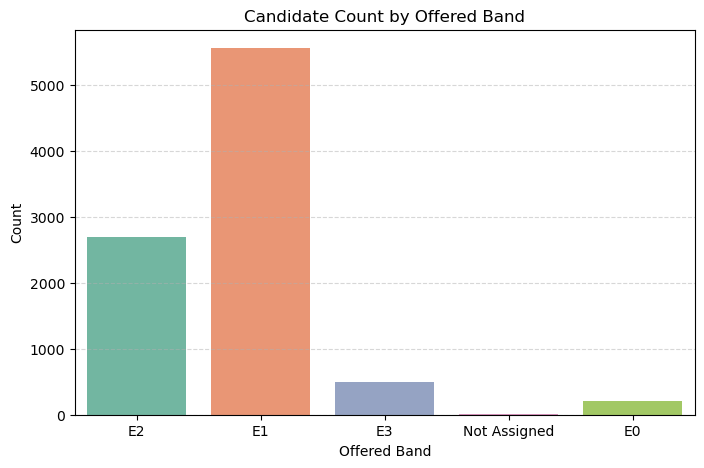

In [48]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Offered_Band",
    hue="Offered_Band",
    palette="Set2",
    legend=False
)

plt.xlabel("Offered Band")
plt.ylabel("Count")
plt.title("Candidate Count by Offered Band")
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.show()

In [49]:
data[data['Offered_Band'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name


In [50]:
data[data['Offered_Band'] == 'E1'].head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
5,6,2117167,Yes,17,30,E1,42.83,42.83,0.00,No,...,34.0,2,D24,Joined,2013-02-03,INFRA,West Bengal,Noida,R1,North
7,8,2127572,Yes,16,0,E1,-20.00,-20.00,0.00,No,...,34.0,3,D6,Joined,2013-02-16,Healthcare,Goa,Noida,R1,North
8,9,2138169,No,1,30,E1,-22.22,-22.22,0.00,No,...,26.0,4,D5,Joined,2013-02-16,BFSI,Delhi,Gurgaon,R1,North
9,10,2143362,No,6,30,E1,240.00,220.00,-20.00,No,...,34.0,5,D23,Joined,2013-03-07,CSMP,Uttarkhand,Chennai,R2,South
18,19,2173730,No,1,30,E1,-13.42,42.86,56.28,No,...,34.0,2,D7,Joined,2013-05-14,INFRA,Gujarat,Gurgaon,R1,North


As there is only only 13 missing values in column `Offered_Band`, we can replace this with the `Mode` of the column i.e. E1

In [51]:
OB_mode = data['Offered_Band'].mode()[0]
OB_mode

'E1'

### Filling `Offered_Band` with `Mode` i.e. `E1`

In [52]:
data['Offered_Band'].fillna(OB_mode, inplace = True)

In [53]:
data['Offered_Band'].isna().sum()

np.int64(0)

In [54]:
data['Offered_Band'].value_counts()

Offered_Band
E1              5565
E2              2704
E3               502
E0               211
Not Assigned      13
Name: count, dtype: int64

## Treatment of `Location_ID` column

In [65]:
data['Location_ID']

0       L001
1       L002
2       L001
3       L001
4       L001
        ... 
8990    L002
8991    L002
8992    L001
8993    L001
8994    L002
Name: Location_ID, Length: 8995, dtype: object

In [56]:
data['Location_ID'].isna().sum()
# This showing no NULL values.

np.int64(0)

In [57]:
data['Location_ID'].value_counts()

# But here we can see there are 13 NULL valued Rows as Null is in Object type

Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

In [58]:
data[data['Location_ID'] == 'Null']

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
220,221,3110300,Yes,15,30,E1,42.83,42.83,0.00,No,...,26.0,2,D16,Joined,2013-08-06,INFRA,Odisha,NaN,NaN,NaN
289,290,3318393,Yes,0,30,E1,92.54,80.51,-12.03,No,...,23.0,2,D14,Joined,2013-11-16,INFRA,Maharashtra,NaN,NaN,NaN
449,450,2128714,Yes,41,45,E1,20.00,4.00,-16.00,No,...,33.0,7,D2,Joined,2014-05-24,AXON,Bihar,NaN,NaN,NaN
1157,1158,2222607,Yes,11,30,E1,42.86,42.86,0.00,No,...,28.0,2,D18,Joined,2013-05-14,INFRA,Rajasthan,NaN,NaN,NaN
2027,2028,2356982,Yes,1,90,E2,50.00,50.00,0.00,No,...,31.0,2,D24,Joined,2013-08-30,INFRA,West Bengal,NaN,NaN,NaN
2562,2563,2394715,Yes,9,30,E1,34.62,34.62,0.00,No,...,30.0,2,D10,Joined,2013-11-16,INFRA,Jharkhand,NaN,NaN,NaN
2774,2775,2419719,Yes,10,30,E1,86.89,86.89,0.00,No,...,35.0,2,D20,Joined,2013-10-18,INFRA,Telangana,NaN,NaN,NaN
2790,2791,2419919,Yes,20,30,E1,6.48,6.48,0.00,No,...,31.0,2,D8,Joined,2013-10-25,INFRA,Haryana,NaN,NaN,NaN
6941,6942,3304772,Yes,0,30,E1,48.15,57.41,9.26,No,...,27.0,2,D8,Joined,2013-12-22,INFRA,Haryana,NaN,NaN,NaN
7312,7313,3347807,No,4,30,E1,33.33,33.33,0.00,No,...,34.0,2,D18,Joined,2013-12-27,INFRA,Rajasthan,NaN,NaN,NaN


### Plot of `Location_ID`

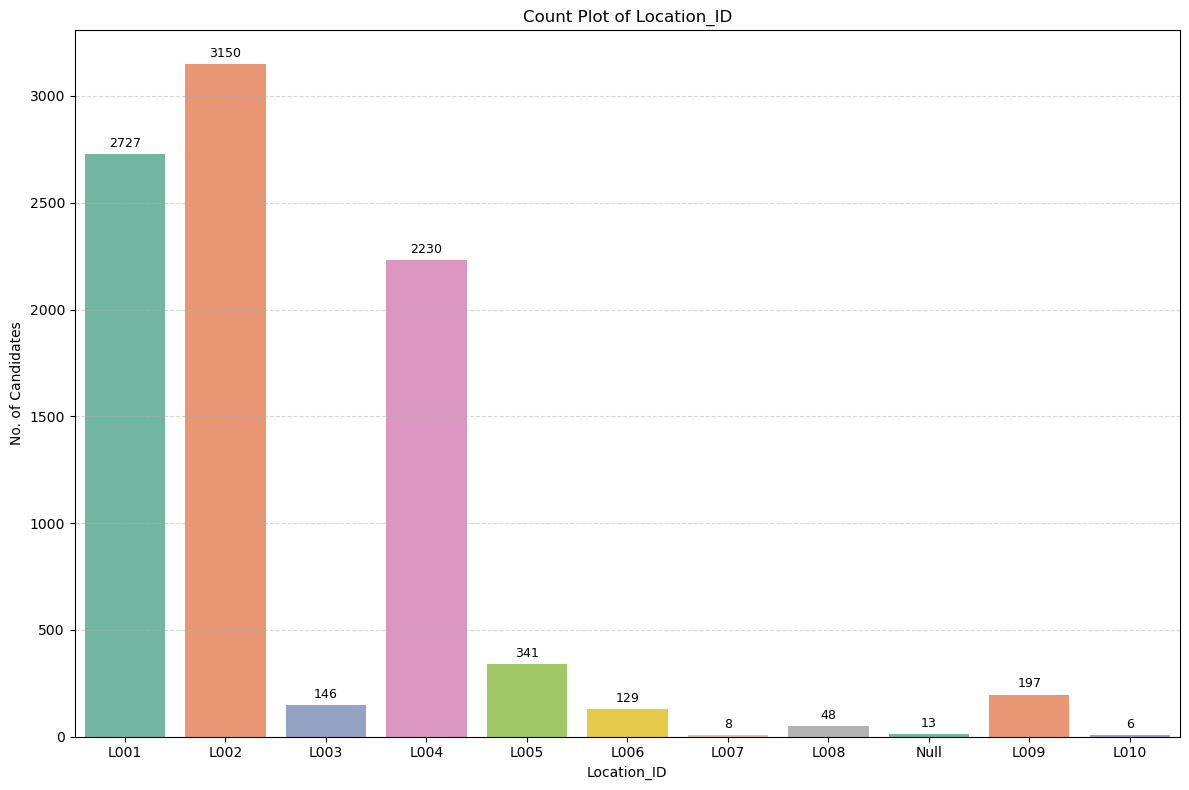

In [59]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_ID",
    hue="Location_ID",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As there is 13 NULL values and there are some Location_ID(s) which have value_counts less than the
NULL, so in this case `replcaing NULL with "Unknown"` will be a good choice.

In [60]:
data["Location_ID"] = data["Location_ID"].replace("Null", "Unknown")

In [61]:
data['Location_ID'].value_counts()

Location_ID
L002       3150
L001       2727
L004       2230
L005        341
L009        197
L003        146
L006        129
L008         48
Unknown      13
L007          8
L010          6
Name: count, dtype: int64

In [62]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

### Treatment of `Location_Name`

In [72]:
LN_NULL = data['Location_Name'].isna().sum()

print(f"No of Null values in Location_Name = {LN_NULL}")

No of Null values in Location_Name = 13


In [73]:
data['Location_Name'].value_counts()

Location_Name
Chennai      3150
Noida        2727
Bangalore    2230
Hyderabad     341
Mumbai        197
Gurgaon       146
Kolkata       129
Pune           48
Cochin          8
Ahmedabad       6
Name: count, dtype: int64

In [74]:
data['Location_Name'].unique()

array(['Noida', 'Chennai', 'Gurgaon', 'Bangalore', 'Hyderabad', 'Kolkata',
       'Cochin', 'Pune', nan, 'Mumbai', 'Ahmedabad'], dtype=object)

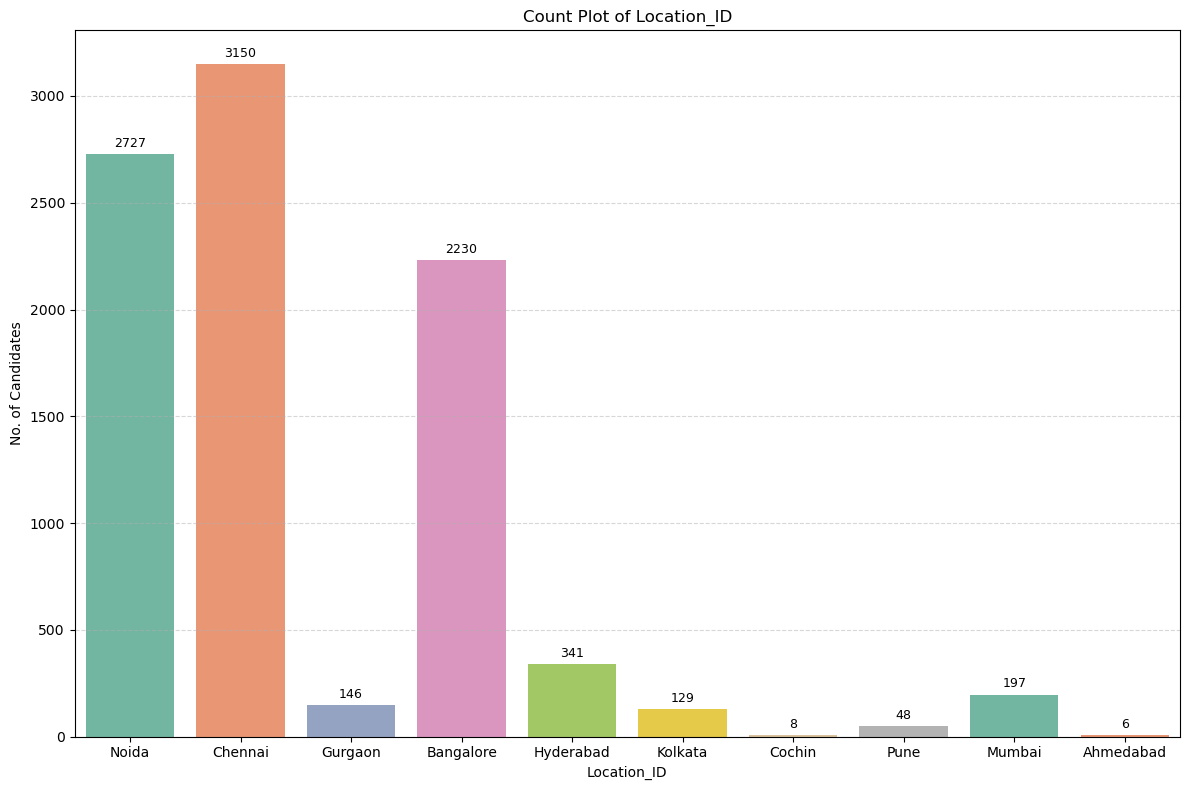

In [75]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_Name",
    hue="Location_Name",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As we have replced `NULL` with `Unknown` in Location_ID column.

In Location_Name going to do Same. 
Replacing `NULL` with `Unknown`

One thing to notice, in *Location_ID* column NULL values were as in Object dtype.

But in *Location_Name* column its in NULL format not in Object dtype.

So `.replace("Null" , "Unknown")` will not work, have to do `fillna()`

In [76]:
data['Location_Name'].fillna("Unknown", inplace = True)

In [77]:
data['Location_Name'].isna().sum()

np.int64(0)

#### Treatment of `Region_Id` column

In [78]:
data['Region_Id']

0       R1
1       R2
2       R1
3       R1
4       R1
        ..
8990    R2
8991    R2
8992    R1
8993    R1
8994    R2
Name: Region_Id, Length: 8995, dtype: object

In [79]:
data['Region_Id'].isna().sum()

np.int64(13)

In [80]:
data['Region_Id'].value_counts()

Region_Id
R2    5729
R1    2873
R4     251
R3     129
Name: count, dtype: int64

- Here we can see in `Region_Id` column the Null is in normal NULL format.

- But if we will do `.fillna("Unknown")` there will be only 13 values in `Unknown` bin.

- In this case as fillna("Unknown") can cause Data Imbalance that can directly affect the Model Performance.
So, Filling NULL with `Mode value(R2)` will be a safer option in this case.

In [81]:
RID_Mode = data['Region_Id'].mode()[0]

print(f"Mode of Region_Id column = {RID_Mode}")

Mode of Region_Id column = R2


In [82]:
data['Region_Id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Region_Id
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [84]:
# Filling NULL values in Region_Id with 'R2'
data['Region_Id'].fillna('R2', inplace = True)

In [85]:
data['Region_Id'].isna().sum()

np.int64(0)

## Treatment of `Region_Name` column

In [88]:
data['Region_Name']

0       North
1       South
2       North
3       North
4       North
        ...  
8990    South
8991    South
8992    North
8993    North
8994    South
Name: Region_Name, Length: 8995, dtype: object

In [89]:
RName_Null = data['Region_Name'].isna().sum()

print(f"Count of Null values in Region_Name column = {RName_Null}")

Count of Null values in Region_Name column = 13


In [94]:
data[['Region_Id','Region_Name']].value_counts()

Region_Id  Region_Name
R2         South          5729
R1         North          2873
R4         West            251
R3         East            129
Name: count, dtype: int64

- As we can see R2 is the South
- And in `Region_Id` column we have replaced NULL with `Mode("E2")`
- So here in `Region_Name` we have to fill NULL with `Mode("South")`

In [95]:
RN_Mode = data['Region_Name'].mode()[0]

print(f"Mode of Region_Name = {RN_Mode}")

Mode of Region_Name = South


In [96]:
# Replacing NULL with "South"

data['Region_Name'].fillna("South" , inplace = True)

In [97]:
data['Region_Name'].isna().sum()

np.int64(0)

In [98]:
data.isna().sum()

Sno                          0
Candidate_ID                 0
DOJ_Extended                 0
Acceptance_days              0
Notice_Period                0
Offered_Band                 0
Expected_CTC_hike_pct        0
Offered_CTC_hike_pct         0
CTC_diff_pct                 0
Joining_Bonus                0
Candidate_relocate_actual    0
Gender                       0
Candidate_Source             0
Experience_years             0
Location_ID                  0
Postal_Code                  0
Age                          0
LOB_Id                       0
Domicile_Id                  0
Status                       0
Date_of_Interview            0
LOB                          0
Domicile_Name                0
Location_Name                0
Region_Id                    0
Region_Name                  0
dtype: int64

### Null Value Treatment Done.

`There is no more NULL values in any column`